In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs

In [12]:
X, y = make_blobs(
  n_samples=500, centers=3, 
  random_state=42, 
  cluster_std=[1.0, 1.5, 0.8]
)

In [13]:
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X)
labels = gmm.predict(X)

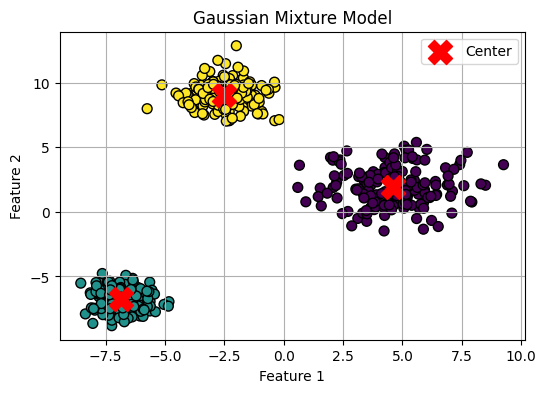

In [14]:
plt.figure(figsize=(6, 4))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50, edgecolors='k')
plt.scatter(
  gmm.means_[:,0],
  gmm.means_[:,1],
  s=300, c='red', marker='X', label='Center'
)

plt.title("Gaussian Mixture Model")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid()
plt.legend()
plt.show()

**Implementation of covarience types**

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.mixture import GaussianMixture

In [24]:
wine = load_wine()
X = wine.data[:,:2]

In [25]:
n_components = 2 # clusters
covarience_types = ['full', 'tied', 'diag', 'spherical']

In [26]:
gmm_models = {cov_type: GaussianMixture(n_components=n_components, covariance_type=cov_type) for cov_type in covarience_types}

for cov_types, gmm_model in gmm_models.items():
  gmm_model.fit(X)

In [27]:
covariences = {
  cov_type: gmm_model.covariances_ for cov_type, gmm_model in gmm_models.items()
}

In [28]:
predictions = {
  cov_type: gmm_model.predict(X) for cov_type, gmm_model in gmm_models.items()
}

Covarience matrix (full - Components):
[[0.56212312 0.35649231]
 [0.35649231 1.20287491]]
Covarience matrix (tied - Components):
[0.65472811 0.06104194]
Covarience matrix (diag - Components):
[0.77470501 0.13064663]
Covarience matrix (spherical - Components):
0.5265050390881795


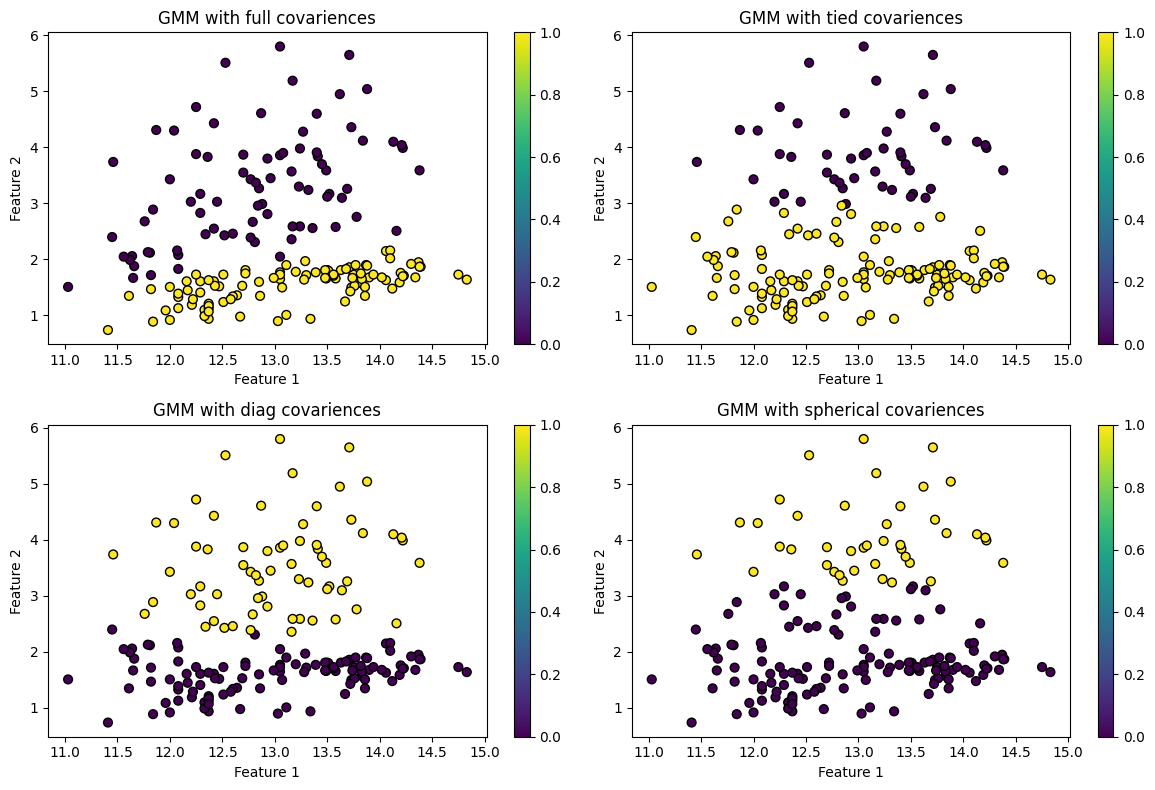

In [29]:
plt.figure(figsize=(12, 8))

for i, (cov_type, gmm_model) in enumerate(gmm_models.items(), 1):
  plt.subplot(2, 2, i)
  plt.scatter(X[:,0], X[:,1], c=predictions[cov_type], cmap='viridis', edgecolors='k', s=40)
  plt.title(f"GMM with {cov_type} covariences")
  plt.xlabel("Feature 1")
  plt.ylabel("Feature 2")
  plt.colorbar()

  print(f"Covarience matrix ({cov_type} - Components):\n{covariences[cov_type][0]}")

plt.tight_layout()
plt.show()